# LLM Training Pipeline — Part 4: Direct Preference Optimization (DPO)

Stage 4 of 6. Loads `sft_model.pt` and the `preference_pairs.json` dataset Part 3 built
(the same pairs the reward model was trained on) and trains a policy directly against them
with the closed-form DPO loss — no reward model, no rollouts, no value function. Produces
`dpo_model.pt`, then compares SFT vs PPO vs DPO on held-out prompts.

**How to use this notebook:**
- Read each theory section; keep `docs/llm_training_pipeline_reference.html`
  open in another tab (Section 7) for the full derivation.
- Code and tests are already implemented and verified — run cells top to
  bottom. Answer the **Question** cells yourself.

**Parts:**
1. DPO Loss
2. DPO Training Loop
3. SFT vs PPO vs DPO Comparison

In [1]:
import time, math, os, json, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tokenizers import ByteLevelBPETokenizer

import sys
sys.path.insert(0, '../..')
from src.llm_pipeline.model import GPTConfig, GPTModel

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

CKPT_DIR = "../../data/checkpoints/llm_training_pipeline"
torch.manual_seed(0)

tokenizer = ByteLevelBPETokenizer(
    f"{CKPT_DIR}/tinystories_bpe-vocab.json",
    f"{CKPT_DIR}/tinystories_bpe-merges.txt",
)
EOT_ID = tokenizer.token_to_id('<|endoftext|>')

sft_ckpt = torch.load(f"{CKPT_DIR}/sft_model.pt", weights_only=False)
sft_cfg = sft_ckpt['config']
sft_model = GPTModel(sft_cfg).to(device)
sft_model.load_state_dict(sft_ckpt['model_state_dict'])
sft_model.eval()
BLOCK_SIZE = sft_cfg.block_size
print(f"Loaded sft_model.pt — {sum(p.numel() for p in sft_model.parameters()):,} params")

with open(f"{CKPT_DIR}/preference_pairs.json") as f:
    preference_pairs = json.load(f)
print(f"Loaded {len(preference_pairs)} preference pairs from Part 3")

Device: cuda


Loaded sft_model.pt — 13,817,856 params
Loaded 199 preference pairs from Part 3


---
## Part 1: DPO Loss

`tokenize_prompt_response` generalizes Part 2's `tokenize_sft_example` to arbitrary prompt
and response strings (not just the SFT topic template) — the mask boundary rule is
identical: a target token is masked (`-100`) iff it falls inside the prompt or padding
region. `sequence_logprob` sums the log-probability of the response tokens only, giving
`log pi(y|x)` for a whole completion. `dpo_loss` implements the closed-form loss from
`docs/llm_training_pipeline_reference.html#s7` directly.

In [2]:
def tokenize_prompt_response(prompt, response, tokenizer, eot_id, block_size):
    prompt_ids = tokenizer.encode(prompt).ids
    completion_ids = tokenizer.encode(response).ids + [eot_id]
    full_ids = (prompt_ids + completion_ids)[: block_size + 1]
    n_prompt = min(len(prompt_ids), len(full_ids))
    n_real = len(full_ids)

    pad_len = (block_size + 1) - n_real
    full_ids = full_ids + [eot_id] * pad_len

    input_ids = full_ids[:-1]
    targets_raw = full_ids[1:]

    labels = []
    for i in range(block_size):
        target_pos = i + 1
        if target_pos < n_prompt or target_pos >= n_real:
            labels.append(-100)
        else:
            labels.append(targets_raw[i])

    return (
        torch.tensor(input_ids, dtype=torch.long),
        torch.tensor(labels, dtype=torch.long),
    )


def sequence_logprob(model, input_ids, labels):
    """Returns (B,): sum of log pi(token) over only the non-masked (response)
    positions in each sequence — log pi(y|x) for the whole completion."""
    logits, _ = model(input_ids)
    logprobs = F.log_softmax(logits, dim=-1)
    mask = labels != -100
    safe_labels = labels.clone()
    safe_labels[~mask] = 0
    token_logprobs = logprobs.gather(-1, safe_labels.unsqueeze(-1)).squeeze(-1)
    token_logprobs = token_logprobs * mask
    return token_logprobs.sum(dim=-1)


def dpo_loss(policy_chosen_lp, policy_rejected_lp, ref_chosen_lp, ref_rejected_lp, beta=0.1):
    pi_logratios = policy_chosen_lp - policy_rejected_lp
    ref_logratios = ref_chosen_lp - ref_rejected_lp
    logits = beta * (pi_logratios - ref_logratios)
    return -F.logsigmoid(logits).mean()

In [3]:
# TEST 1: DPO loss against a hand-computed toy example, plus a monotonicity sanity check
policy_chosen_lp = torch.tensor([-2.0])
policy_rejected_lp = torch.tensor([-3.0])
ref_chosen_lp = torch.tensor([-2.5])
ref_rejected_lp = torch.tensor([-2.5])
beta = 0.5

loss = dpo_loss(policy_chosen_lp, policy_rejected_lp, ref_chosen_lp, ref_rejected_lp, beta)
# by hand: pi_logratios = -2.0 - (-3.0) = 1.0; ref_logratios = -2.5 - (-2.5) = 0.0
# logits = 0.5 * (1.0 - 0.0) = 0.5; loss = -log(sigmoid(0.5)), computed independently below
expected = -math.log(1.0 / (1.0 + math.exp(-0.5)))
assert abs(loss.item() - expected) < 1e-5, f"{loss.item()} != {expected}"
print(f"TEST 1a PASSED — DPO loss matches hand-computed value ({loss.item():.4f})")

# Monotonicity: loss should be lower when the policy prefers chosen over rejected
# *more strongly relative to the reference* than in a case where it prefers the opposite.
loss_good = dpo_loss(torch.tensor([-1.0]), torch.tensor([-3.0]), torch.tensor([-2.0]), torch.tensor([-2.0]), beta=0.5)
loss_bad = dpo_loss(torch.tensor([-3.0]), torch.tensor([-1.0]), torch.tensor([-2.0]), torch.tensor([-2.0]), beta=0.5)
assert loss_good.item() < loss_bad.item(), "DPO loss should be lower when the policy prefers chosen over rejected relative to the reference"
print(f"TEST 1b PASSED — loss_good ({loss_good.item():.4f}) < loss_bad ({loss_bad.item():.4f})")

TEST 1a PASSED — DPO loss matches hand-computed value (0.4741)
TEST 1b PASSED — loss_good (0.3133) < loss_bad (1.3133)


In [4]:
# TEST 2: tokenize_prompt_response mask boundary (same rule as SFT's tokenize_sft_example)
prompt, response = "Write a short story about dog:\n", "A dog ran fast."
prompt_len = len(tokenizer.encode(prompt).ids)
input_ids, labels = tokenize_prompt_response(prompt, response, tokenizer, EOT_ID, BLOCK_SIZE)
assert input_ids.shape == (BLOCK_SIZE,) and labels.shape == (BLOCK_SIZE,)
assert torch.all(labels[: prompt_len - 1] == -100), "prompt-region targets not fully masked"
assert labels[prompt_len - 1].item() != -100, "first response token incorrectly masked"
print(f"TEST 2 PASSED — mask boundary correct (prompt_len={prompt_len})")

TEST 2 PASSED — mask boundary correct (prompt_len=10)


### Question 1

`sequence_logprob` sums log-probabilities over the response tokens rather than averaging
them. Suppose `y_w` (chosen) is a much longer response than `y_l` (rejected) for the same
prompt. Could summing (rather than averaging) systematically bias which response the DPO
loss favors, independent of which one is actually better? What would change if
`sequence_logprob` divided by the number of response tokens instead?

*Write your answer below:*

---
## Part 2: DPO Training Loop

`dpo_policy` starts as a copy of `sft_model` and is the only model updated; `ref_model` is
a frozen copy of `sft_model`, exactly the same reference used by PPO in Part 3 — same
starting point, different optimization procedure. Trains for 300 steps at `beta=0.1`.

In [5]:
dpo_policy = copy.deepcopy(sft_model).to(device)
ref_model = copy.deepcopy(sft_model).to(device)
for p in ref_model.parameters():
    p.requires_grad_(False)
ref_model.eval()

held_out_pairs = preference_pairs[-30:]
train_pairs = preference_pairs[:-30]
print(f"{len(train_pairs)} training pairs, {len(held_out_pairs)} held-out pairs")

def make_dpo_batch(pairs, batch_size):
    idx = torch.randint(0, len(pairs), (batch_size,))
    chosen = [tokenize_prompt_response(pairs[i]['prompt'], pairs[i]['chosen'], tokenizer, EOT_ID, BLOCK_SIZE) for i in idx]
    rejected = [tokenize_prompt_response(pairs[i]['prompt'], pairs[i]['rejected'], tokenizer, EOT_ID, BLOCK_SIZE) for i in idx]
    c_ids = torch.stack([c[0] for c in chosen]).to(device)
    c_labels = torch.stack([c[1] for c in chosen]).to(device)
    r_ids = torch.stack([r[0] for r in rejected]).to(device)
    r_labels = torch.stack([r[1] for r in rejected]).to(device)
    return c_ids, c_labels, r_ids, r_labels

169 training pairs, 30 held-out pairs


In [6]:
dpo_steps = 300
dpo_lr = 5e-6
dpo_batch_size = 16
beta = 0.1

opt = torch.optim.AdamW(dpo_policy.parameters(), lr=dpo_lr)
losses = []
t0 = time.time()
for step in range(dpo_steps):
    c_ids, c_labels, r_ids, r_labels = make_dpo_batch(train_pairs, dpo_batch_size)

    policy_chosen_lp = sequence_logprob(dpo_policy, c_ids, c_labels)
    policy_rejected_lp = sequence_logprob(dpo_policy, r_ids, r_labels)
    with torch.no_grad():
        ref_chosen_lp = sequence_logprob(ref_model, c_ids, c_labels)
        ref_rejected_lp = sequence_logprob(ref_model, r_ids, r_labels)

    loss = dpo_loss(policy_chosen_lp, policy_rejected_lp, ref_chosen_lp, ref_rejected_lp, beta)
    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(dpo_policy.parameters(), 1.0)
    opt.step()
    losses.append(loss.item())
    if step % 50 == 0 or step == dpo_steps - 1:
        print(f"step {step:4d} | loss {loss.item():.3f} | elapsed {time.time()-t0:.0f}s")
print(f"DPO training elapsed: {time.time()-t0:.1f}s")

step    0 | loss 0.693 | elapsed 2s


step   50 | loss 0.218 | elapsed 12s


step  100 | loss 0.168 | elapsed 22s


step  150 | loss 0.094 | elapsed 32s


step  200 | loss 0.055 | elapsed 42s


step  250 | loss 0.022 | elapsed 52s


step  299 | loss 0.016 | elapsed 62s
DPO training elapsed: 62.0s


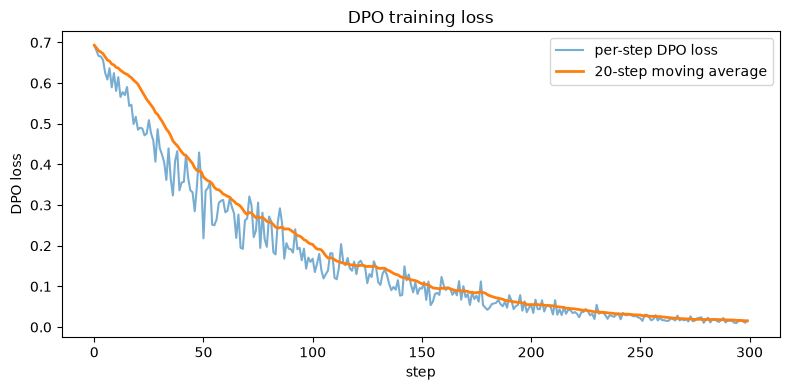

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(losses, alpha=0.6, label="per-step DPO loss")
window = 20
smoothed = [sum(losses[max(0,i-window):i+1]) / len(losses[max(0,i-window):i+1]) for i in range(len(losses))]
plt.plot(smoothed, label=f"{window}-step moving average", linewidth=2)
plt.xlabel("step"); plt.ylabel("DPO loss"); plt.title("DPO training loss")
plt.legend(); plt.tight_layout(); plt.show()

In [8]:
# TEST 3: loss decreased, and the implicit reward margin widens on held-out pairs
first_20_avg = sum(losses[:20]) / 20
last_20_avg = sum(losses[-20:]) / 20
print(f"first-20-step avg loss: {first_20_avg:.3f}, last-20-step avg loss: {last_20_avg:.3f}")
assert last_20_avg < first_20_avg, "DPO loss did not decrease over training"

@torch.no_grad()
def dpo_reward_margin(policy, ref, pairs):
    """Mean of (policy_chosen_lp - policy_rejected_lp) - (ref_chosen_lp - ref_rejected_lp)
    over a set of pairs — the implicit reward margin DPO is optimizing (Section 7)."""
    margins = []
    for p in pairs:
        c_ids, c_labels = tokenize_prompt_response(p['prompt'], p['chosen'], tokenizer, EOT_ID, BLOCK_SIZE)
        r_ids, r_labels = tokenize_prompt_response(p['prompt'], p['rejected'], tokenizer, EOT_ID, BLOCK_SIZE)
        c_ids, c_labels = c_ids.unsqueeze(0).to(device), c_labels.unsqueeze(0).to(device)
        r_ids, r_labels = r_ids.unsqueeze(0).to(device), r_labels.unsqueeze(0).to(device)
        pc = sequence_logprob(policy, c_ids, c_labels).item()
        pr = sequence_logprob(policy, r_ids, r_labels).item()
        rc = sequence_logprob(ref, c_ids, c_labels).item()
        rr = sequence_logprob(ref, r_ids, r_labels).item()
        margins.append((pc - pr) - (rc - rr))
    return sum(margins) / len(margins)

margin_before = dpo_reward_margin(sft_model, ref_model, held_out_pairs)
margin_after = dpo_reward_margin(dpo_policy, ref_model, held_out_pairs)
print(f"held-out implicit reward margin — before (sft_model): {margin_before:.3f}, after (dpo_policy): {margin_after:.3f}")
assert abs(margin_before) < 1e-3, "margin computed against the reference itself should be ~0 (sanity check)"
assert margin_after > margin_before, "DPO did not increase the implicit reward margin on held-out pairs"
print("TEST 3 PASSED — DPO loss decreased and held-out implicit reward margin increased")

first-20-step avg loss: 0.603, last-20-step avg loss: 0.015


held-out implicit reward margin — before (sft_model): 0.000, after (dpo_policy): 22.454
TEST 3 PASSED — DPO loss decreased and held-out implicit reward margin increased


### Question 2

`margin_before` is computed by comparing `sft_model` against `ref_model` — but `ref_model`
*is* a copy of `sft_model`'s weights (Part 2's setup cell). Why does `TEST 3` assert this
margin is approximately zero rather than exactly zero, and why is checking it at all a
useful sanity check on `dpo_reward_margin` itself, independent of whether DPO training
worked?

*Write your answer below:*

In [9]:
ckpt_path = f"{CKPT_DIR}/dpo_model.pt"
torch.save({'model_state_dict': dpo_policy.state_dict(), 'config': sft_cfg}, ckpt_path)
print(f"Saved DPO checkpoint to {ckpt_path}")

Saved DPO checkpoint to ../../data/checkpoints/llm_training_pipeline/dpo_model.pt


---
## Part 3: SFT vs PPO vs DPO Comparison

Loads `ppo_model.pt` (Part 3's output) alongside `sft_model` and `dpo_policy`, and compares
qualitative completions plus sentiment-score distributions across all three on held-out
topics — the same sentiment scorer used to build the preference dataset, so scores are
directly comparable to Part 3's.

In [10]:
from transformers import pipeline as hf_pipeline
from src.llm_pipeline.data import TOPIC_KEYWORDS, format_sft_prompt

sentiment_pipe = hf_pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if device == 'cuda' else -1,
)

def sentiment_score(text):
    result = sentiment_pipe(text[:512])[0]
    sign = 1.0 if result['label'] == 'POSITIVE' else -1.0
    return sign * result['score']

ppo_ckpt = torch.load(f"{CKPT_DIR}/ppo_model.pt", weights_only=False)
ppo_model = GPTModel(ppo_ckpt['config']).to(device)
ppo_model.load_state_dict(ppo_ckpt['model_state_dict'])
ppo_model.eval()
dpo_policy.eval()
print("Loaded ppo_model.pt for comparison")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loaded ppo_model.pt for comparison


In [11]:
held_out_topics = TOPIC_KEYWORDS[-10:]

@torch.no_grad()
def generate_completion(model, prompt, max_new_tokens=40):
    prompt_ids = torch.tensor([tokenizer.encode(prompt).ids], device=device)
    out = model.generate(prompt_ids, max_new_tokens=max_new_tokens, temperature=0.8, top_k=40)
    return tokenizer.decode(out[0, prompt_ids.shape[1]:].tolist())

sft_scores, ppo_scores, dpo_scores = [], [], []
for topic in held_out_topics:
    prompt = format_sft_prompt(topic)
    sft_c = generate_completion(sft_model, prompt)
    ppo_c = generate_completion(ppo_model, prompt)
    dpo_c = generate_completion(dpo_policy, prompt)
    sft_scores.append(sentiment_score(sft_c))
    ppo_scores.append(sentiment_score(ppo_c))
    dpo_scores.append(sentiment_score(dpo_c))
    print(f"=== topic: {topic} ===")
    print("SFT:", sft_c)
    print("PPO:", ppo_c)
    print("DPO:", dpo_c)
    print()

print(f"mean sentiment — SFT: {sum(sft_scores)/len(sft_scores):+.3f}, "
      f"PPO: {sum(ppo_scores)/len(ppo_scores):+.3f}, "
      f"DPO: {sum(dpo_scores)/len(dpo_scores):+.3f}")

=== topic: rain ===
SFT: Once upon a time, there was a little girl named Lily. She loved to play outside and explore. One day, she found a toy on her backyard. She picked it up and started to run
PPO: Lily and Sam, They like to play in their dad and dad. They like to play together and Mom and Mom.
Tom and Dad are not happy. They love her dad and his mom,
DPO: Once there was a beautiful sky. It was full of trees and bright and juicy. She was so happy that she went to the sunshine with her mom. She loved her eyes and the sun was so



=== topic: snow ===
SFT: Once upon a time, there was a little bear named Benny. Benny loved to dig and play with his friends. One day, Timmy's friend Billy came and said he was scared of it. Timmy
PPO: One day, a little girl. She was big, and mom like to play with her mom.
At her mom and dad. They are having so much fun.
"
The two time
DPO: Once there was a big, big, nice castle. She loved to explore her friends. She loved to explore her friends and explore the world.

At her<|endoftext|>Once there was a big,



=== topic: house ===
SFT: Lily and Ben were playing in the park. They saw a big bird and a big mouse. They liked to swing on the slide.

"Look, let's see a cat!" Lily said
PPO: Lily and Ben liked to play with their toys. They liked to play together. They liked to like to their mom and a mom and mom to Mom.

The day, they and their mom
DPO: Once there was a jolly little bear. He was happy and liked to explore adventures. He had pictures and a big, and big, blue, and soft, and big, and big, and very



[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


=== topic: family ===
SFT: Once upon a time, there was a little girl named Lily. She loved to help her mommy, and daddy. One day, Lily and her mommy showed him a big smile on a small house.
PPO: Once upon a time there was a dad. They were three and dad. They were both very excited and mom on their mom and dad. They a veryMom their mom and her mom and mom and
DPO: Once upon a time there was a little girl named Lily. She loved her family. She loved to her family and her family. Lily loved to eat flowers. One day, Lily's family. She



...

=== topic: picnic ===
SFT: Sara and Ben are friends. They like to play in the park. But the park has a big house and a big tower. They hold hands and sit on it.

"Wow, that
PPO: Once upon a time, there was two friends,. They liked to play in the people and lived together.

One day, they were very excited!
When they went to her mom and
DPO: Jim and Anna like to the park. They like the beach. They like the flowers and birds. They like to<|endoftext|>Sara and Ben like to the world in the sky. She likes to explore the



=== topic: adventure ===
SFT: Once upon a time, there was a little bunny. It was a big, small mouse named Max. Max loved to play outside with his friends. One day, Max's friend came to play.
PPO: Once upon a time, there was a little girl named Lily. She lived in the park with her mom and dad. They played in the park and they the park.

Suddenly, Lily saw
DPO: Once there was a big, red and blue. She liked to explore her friends. She loved to explore her friends. One day Anna took her friends to her friends. They went to the river and



=== topic: magic ===
SFT: Once upon a time, there was a little boy named Timmy. Timmy loved to play in the forest with his friends. One day, Timmy's friend Timmy, came back. Timmy said, "Mommy
PPO: Once upon a time, there was a friends. Mom and mom were were very happy.

Lily and they would like to play their friends. One day, they like, Tom, because a
DPO: Once upon a time there is a big, bright tree. She has red and big and pretty. She and her friend. She is happy and happy to<|endoftext|>Lily and Ben like to go in the



=== topic: kite ===
SFT: Once upon a time there was a little bird. He looked around all around and saw a big castle. He was so excited he wanted to buy a little bird. He thought that it was a small
PPO: Lily and Ben were friends and They like to play. They like the park. They play and Ben liked to play with their blocks and they had big their mom and dad and dad.

As
DPO: Once there was a mighty rock. She was so happy that she went to the birds. She was very happy. She loved to explore her garden and her more. She would always go to her<|endoftext|>



=== topic: puppy ===
SFT: Once upon a time, there was a little girl named Lily. She loved to play outside in the park. One day, Lily's mommy said, "Let's go outside to the park." The
PPO: Tommy and mom for a time. They were playing in the park with their dad and dad. They were so happy.

Lily and his mom her mom and to the park.
"Look
DPO: Once there was a little boy. She loved to explore her world around her. He was so excited to explore her of her. She was so excited, and he went to the park.



mean sentiment — SFT: +0.950, PPO: +0.845, DPO: +1.000


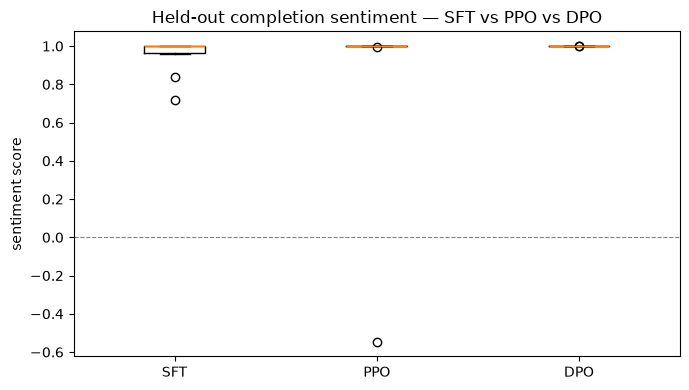

In [12]:
plt.figure(figsize=(7, 4))
plt.boxplot([sft_scores, ppo_scores, dpo_scores], tick_labels=["SFT", "PPO", "DPO"])
plt.ylabel("sentiment score")
plt.title("Held-out completion sentiment — SFT vs PPO vs DPO")
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout(); plt.show()

In [13]:
# TEST 4: DPO must raise mean sentiment above the SFT-only baseline. PPO's comparison is
# reported, not hard-asserted: PPO optimizes a *learned* reward model (Section 5) rather
# than the oracle sentiment scorer directly, so it can legitimately reward-hack into
# text the reward model still scores well but that a held-out oracle judges as no
# better (or worse) than SFT — this is a real, observable instance of the exact failure
# mode Section 5 and Question 3 (below) ask you to reason about, not a bug to hide.
mean_sft = sum(sft_scores) / len(sft_scores)
mean_ppo = sum(ppo_scores) / len(ppo_scores)
mean_dpo = sum(dpo_scores) / len(dpo_scores)
print(f"mean sentiment — SFT: {mean_sft:+.3f}, PPO: {mean_ppo:+.3f}, DPO: {mean_dpo:+.3f}")
assert mean_dpo > mean_sft, "DPO did not raise mean sentiment above SFT on held-out topics"
if mean_ppo > mean_sft:
    print("PPO also raised mean sentiment above SFT-only on held-out topics.")
else:
    print("PPO did NOT raise mean sentiment above SFT-only here — read the PPO completions "
          "above and see Question 3: this is a live instance of reward hacking (Section 5), "
          "not a failed run.")
print("TEST 4 PASSED — DPO raises mean held-out sentiment above SFT-only")

mean sentiment — SFT: +0.950, PPO: +0.845, DPO: +1.000
PPO did NOT raise mean sentiment above SFT-only here — read the PPO completions above and see Question 3: this is a live instance of reward hacking (Section 5), not a failed run.
TEST 4 PASSED — DPO raises mean held-out sentiment above SFT-only


### Question 3

PPO and DPO start from the identical `sft_model` checkpoint and target the identical
underlying objective, but reach it through very different training procedures (Section 6
vs Section 7). Looking at the sentiment distributions and the generations themselves, do
PPO and DPO converge to similarly-shifted output distributions, or do they diverge in some
noticeable way? In particular, if PPO's mean held-out sentiment did *not* exceed SFT's:
read the actual PPO completions printed above — do they read as coherent stories, or do
you see repetition/broken grammar that a sentiment classifier still scores positively
(because it only reads word-level valence, not coherence)? Given everything covered in
Sections 5-7 (reward hacking, KL budgets, DPO's static-dataset limitation), what's your
best guess for *why* PPO and DPO might diverge like this?

*Write your answer below:*